# Cell 1: Import all required libraries

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# load data

In [85]:
df = pd.read_csv(r"dirty_machine_data.csv")
df.head()
sampled = df.sample(n=10000, random_state=42)
sampled.to_csv("sampled_10000.csv", index=False)
df = pd.read_csv('sampled_10000.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,4135,L51314,L,301.8,310.3,1688.0,28.8,31.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6566,L53745,L,301.4,310.6,1550.0,36.8,159.0,0.0,0.0,0.0,0.0,0.0,0.0
2,979,M15838,M,296.2,306.8,1526.0,42.3,129.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1690,L48869,L,297.9,307.5,1561.0,37.7,16.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4477,L51656,L,302.6,310.4,1415.0,52.1,12.0,0.0,0.0,0.0,0.0,0.0,0.0


# Info about dataset

In [86]:
df.shape

(10000, 14)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      9701 non-null   float64
 4   Process temperature [K]  9702 non-null   float64
 5   Rotational speed [rpm]   9702 non-null   float64
 6   Torque [Nm]              9704 non-null   float64
 7   Tool wear [min]          9702 non-null   float64
 8   Machine failure          9705 non-null   float64
 9   TWF                      9704 non-null   float64
 10  HDF                      9696 non-null   float64
 11  PWF                      9698 non-null   float64
 12  OSF                      9703 non-null   float64
 13  RNF                      9696 non-null   float64
dtypes: float64(11), int64(1

In [88]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5009.454000,2881.823263,1.0,2520.75,5015.5,7501.25,10000.0
Air temperature [K],9701.0,300.013906,2.005995,295.3,298.30,300.1,301.50,304.5
Process temperature [K],9702.0,310.015409,1.488129,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],9702.0,1538.718718,178.103155,1168.0,1424.00,1504.0,1612.00,2874.0
Torque [Nm],9704.0,42.394765,20.287143,4.2,33.40,40.3,47.20,278.8
Tool wear [min],9702.0,107.830860,63.594387,0.0,53.00,107.0,162.00,253.0
Machine failure,9705.0,0.032973,0.178574,0.0,0.00,0.0,0.00,1.0
TWF,9704.0,0.004843,0.069429,0.0,0.00,0.0,0.00,1.0
HDF,9696.0,0.010520,0.102030,0.0,0.00,0.0,0.00,1.0
PWF,9698.0,0.009074,0.094829,0.0,0.00,0.0,0.00,1.0


# Cell 3: check for missing value, duplicate and outliers

In [89]:
df.isnull().sum()

UDI                          0
Product ID                   0
Type                         0
Air temperature [K]        299
Process temperature [K]    298
Rotational speed [rpm]     298
Torque [Nm]                296
Tool wear [min]            298
Machine failure            295
TWF                        296
HDF                        304
PWF                        302
OSF                        297
RNF                        304
dtype: int64

In [90]:
df.duplicated().sum()

np.int64(204)

In [91]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

outliers_count = {}
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers_count[c] = ((df[c] < low) | (df[c] > high)).sum()

pd.Series(outliers_count).sort_values(ascending=False)


Rotational speed [rpm]     405
Machine failure            320
Torque [Nm]                241
HDF                        102
OSF                         96
PWF                         88
TWF                         47
RNF                         17
Process temperature [K]      0
Air temperature [K]          0
UDI                          0
Tool wear [min]              0
dtype: int64

# Cleanning

In [92]:
df = df.dropna()

In [93]:
df.drop_duplicates(inplace= True)

In [94]:
df = df.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)


In [95]:
cols_with_missing = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for col in cols_with_missing:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\medo\AppData\Local\Temp\ipykernel_14892\293116681.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\medo\AppData\Local\Temp\ipykernel_14892\293116681.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [96]:

numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers with NaN
    df[col] = np.where(
        (df[col] < lower_bound) | (df[col] > upper_bound),
        np.nan,
        df[col]
    )

# Fill new NaN (from outliers) with median
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\medo\AppData\Local\Temp\ipykernel_14892\4080619574.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\medo\AppData\Local\Temp\ipykernel_14892\4080619574.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [ ]:
import numpy as np
import pandas as pd


num_cols = df.select_dtypes(include=np.number).columns


binary_cols = [c for c in num_cols if df[c].dropna().nunique() <= 2]
exclude_cols = set(binary_cols)

for col in ["Machine failure", "UDI", "Product ID", "ID"]:
    if col in df.columns:
        exclude_cols.add(col)


cont_cols = [c for c in num_cols if c not in exclude_cols]

print("Continuous cols used for outliers:", cont_cols)


df_clipped = df.copy()
for c in cont_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    df_clipped[c] = df_clipped[c].clip(low, high)


before = {}
after = {}

for c in cont_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    before[c] = ((df[c] < low) | (df[c] > high)).sum()

    q1, q3 = df_clipped[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    after[c] = ((df_clipped[c] < low) | (df_clipped[c] > high)).sum()


Continuous cols used for outliers: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


# check cleanning

In [98]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
dtype: int64

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
pd.Series(after).sum()


np.int64(0)

(boxplot)نظري سريع يورينا قبل وبعد

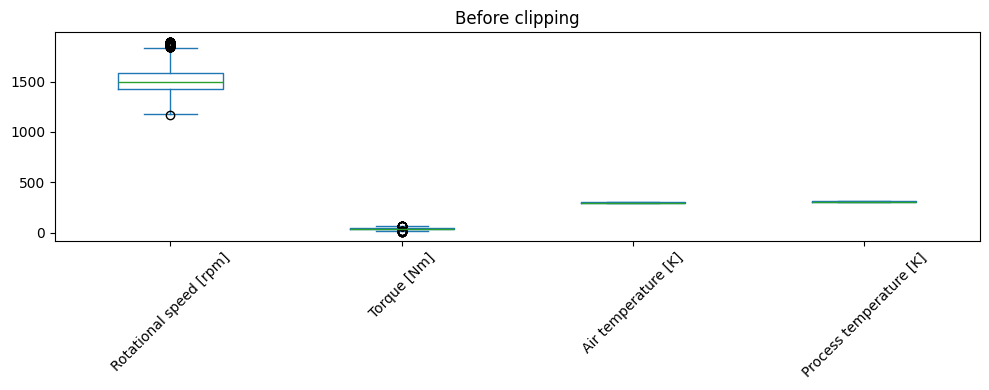

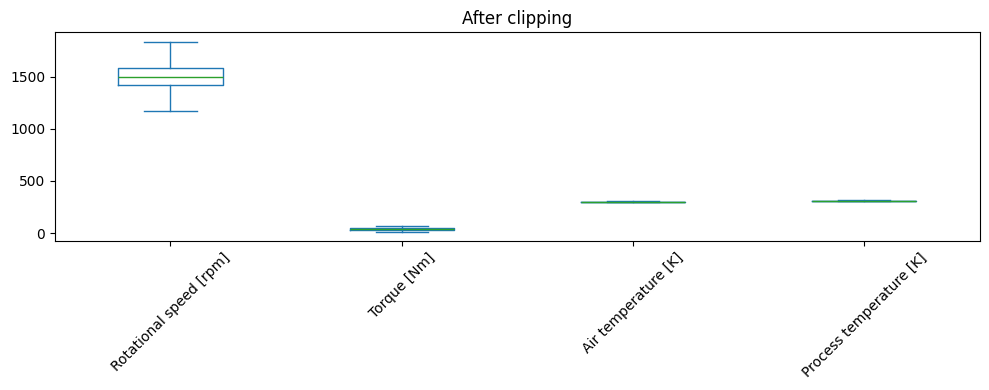

In [101]:
import matplotlib.pyplot as plt

top_cols = pd.Series(before).sort_values(ascending=False).head(4).index

df[top_cols].plot(kind="box", figsize=(10,4), rot=45)
plt.title("Before clipping")
plt.tight_layout()
plt.show()

df_clipped[top_cols].plot(kind="box", figsize=(10,4), rot=45)
plt.title("After clipping")
plt.tight_layout()
plt.show()


# Standardisation & Encoding

In [102]:
df_final = df.drop(columns=['UDI', 'Product ID'])


df_final = pd.get_dummies(df_final, columns=['Type'], drop_first=True)


scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_final), columns=df_final.columns)


print("Final Shape:", df_scaled.shape)
print(df_scaled.head())


df_scaled.to_csv('final_ready_for_clustering.csv', index=False)

Final Shape: (6937, 10)
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0             0.881932                 0.185755                1.371853   
1             0.682634                 0.387853                0.285675   
2            -1.908246                -2.172062                0.096775   
3            -1.061227                -1.700498                0.372255   
4             1.280529                 0.253121               -0.776889   

   Torque [Nm]  Tool wear [min]  Type_H_typo    Type_L  Type_L_typo    Type_M  \
0    -1.169235        -1.216981    -0.051005  0.835811    -0.110713 -0.646776   
1    -0.332651         0.806473    -0.051005  0.835811    -0.110713 -0.646776   
2     0.242500         0.332226    -0.051005 -1.196443    -0.110713  1.546130   
3    -0.238536        -1.454105    -0.051005  0.835811    -0.110713 -0.646776   
4     1.267316        -1.517338    -0.051005  0.835811    -0.110713 -0.646776   

   Type_M_typo  
0    -0.075192  
1   

In [103]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6937 entries, 0 to 6936
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Air temperature [K]      6937 non-null   float64
 1   Process temperature [K]  6937 non-null   float64
 2   Rotational speed [rpm]   6937 non-null   float64
 3   Torque [Nm]              6937 non-null   float64
 4   Tool wear [min]          6937 non-null   float64
 5   Type_H_typo              6937 non-null   float64
 6   Type_L                   6937 non-null   float64
 7   Type_L_typo              6937 non-null   float64
 8   Type_M                   6937 non-null   float64
 9   Type_M_typo              6937 non-null   float64
dtypes: float64(10)
memory usage: 542.1 KB


# Dimensionality Reduction with PCA for visualization

In [ ]:
print("="*50)
print("DIMENSIONALITY REDUCTION (PCA)")
print("="*50)

from sklearn.decomposition import PCA

X_scaled = df_scaled.copy()  
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_scaled.index)

print("Explained variance ratio:", pca_2d.explained_variance_ratio_)
display(pca_df.head())


DIMENSIONALITY REDUCTION (PCA)
Explained variance ratio: [0.188868   0.17821392]


,PC1,PC2
0,1.390012,1.620985
1,1.048647,0.757465
2,-3.066062,-0.372897
3,-1.556188,1.602349
4,0.751420,-0.671088


# K MEANS

K-MEANS CLUSTERING WITH OPTIMAL K SELECTION (Machine Failure)
X_kmeans shape: (6937, 10)
X_kmeans index sample: RangeIndex(start=0, stop=5, step=1)
Using sample size = 5000 for K selection
Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...
Testing k=10...


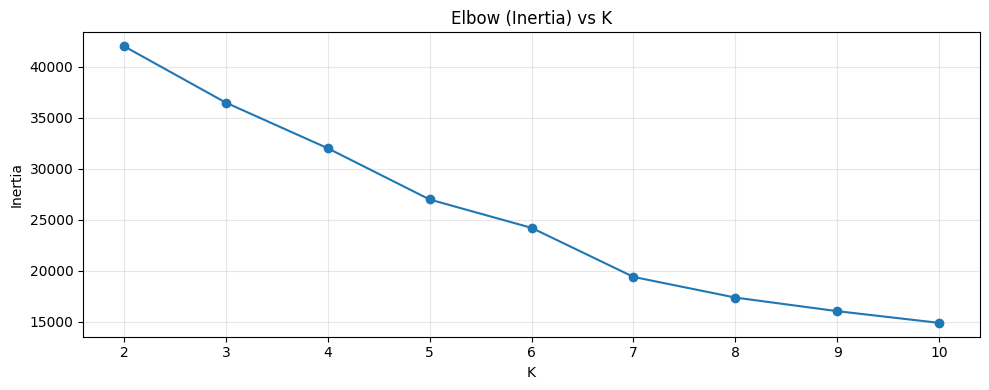

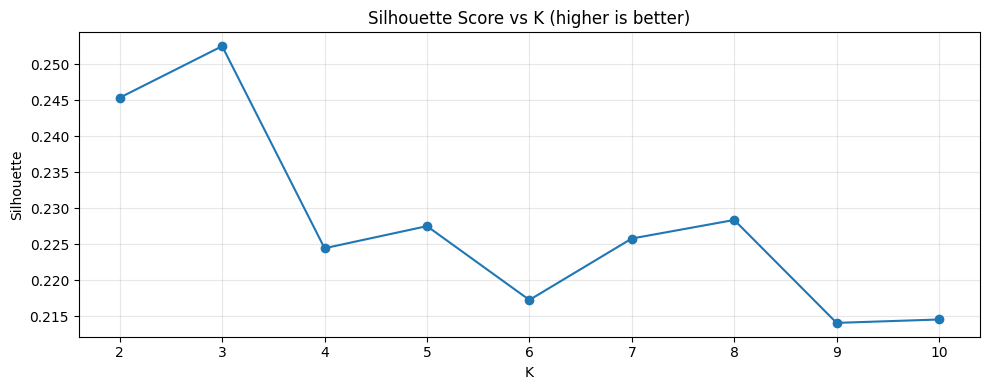

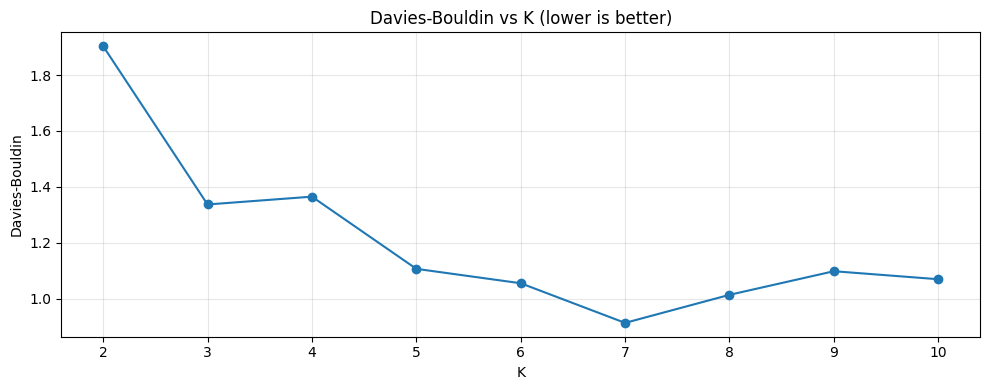

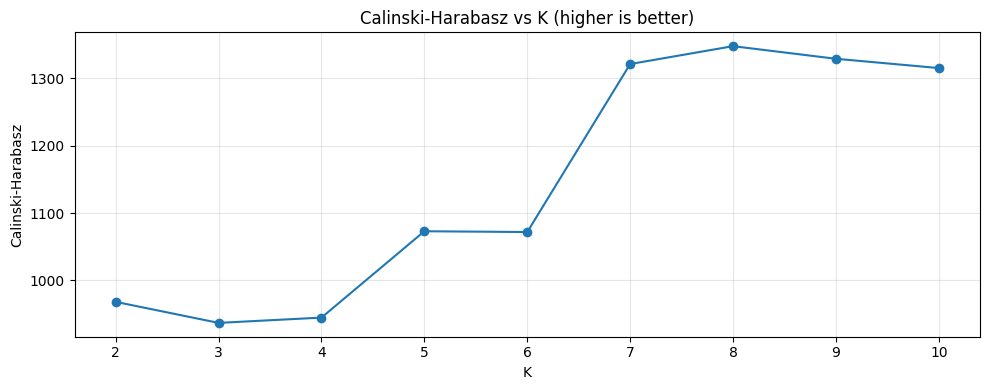


Selected optimal k = 3 (max silhouette on sample)

Final K-Means model trained on FULL data.
Cluster sizes:
0    4084
1    2835
2      18
Name: count, dtype: int64

K-Means Metrics (k=3) [evaluated on sample]:
  Silhouette: 0.2483
  Davies-Bouldin: 1.3232
  Calinski-Harabasz: 917.3904
  Inertia: 51,098.60


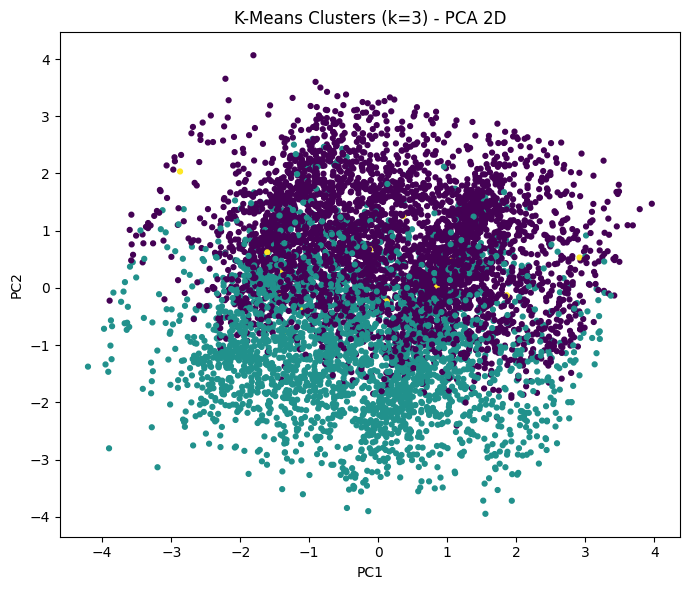

In [ ]:
print("="*50)
print("K-MEANS CLUSTERING WITH OPTIMAL K SELECTION (Machine Failure)")
print("="*50)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA


X_kmeans = df_scaled.copy()   

print("X_kmeans shape:", X_kmeans.shape)
print("X_kmeans index sample:", X_kmeans.index[:5])

sample_n = min(5000, len(X_kmeans))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_kmeans), sample_n, replace=False)
X_kmeans_sample = X_kmeans.iloc[sample_idx]

print(f"Using sample size = {sample_n} for K selection")

k_range = range(2, 11)
inertias, silhouette_scores, davies_scores, calinski_scores = [], [], [], []

for k in k_range:
    print(f"Testing k={k}...")
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_kmeans_sample)

    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_kmeans_sample, labels))
    davies_scores.append(davies_bouldin_score(X_kmeans_sample, labels))
    calinski_scores.append(calinski_harabasz_score(X_kmeans_sample, labels))

plt.figure(figsize=(10,4))
plt.plot(list(k_range), inertias, marker='o')
plt.title("Elbow (Inertia) vs K")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(list(k_range), silhouette_scores, marker='o')
plt.title("Silhouette Score vs K (higher is better)")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(list(k_range), davies_scores, marker='o')
plt.title("Davies-Bouldin vs K (lower is better)")
plt.xlabel("K")
plt.ylabel("Davies-Bouldin")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(list(k_range), calinski_scores, marker='o')
plt.title("Calinski-Harabasz vs K (higher is better)")
plt.xlabel("K")
plt.ylabel("Calinski-Harabasz")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optimal_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"\nSelected optimal k = {optimal_k} (max silhouette on sample)")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
kmeans_labels = kmeans_final.fit_predict(X_kmeans)

print("\nFinal K-Means model trained on FULL data.")
print("Cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

rng2 = np.random.RandomState(7)
sample_idx_final = rng2.choice(len(X_kmeans), sample_n, replace=False)
X_eval = X_kmeans.iloc[sample_idx_final]
labels_eval = kmeans_labels[sample_idx_final]

kmeans_sil = silhouette_score(X_eval, labels_eval)
kmeans_dav = davies_bouldin_score(X_eval, labels_eval)
kmeans_cal = calinski_harabasz_score(X_eval, labels_eval)
kmeans_inertia = kmeans_final.inertia_

print(f"\nK-Means Metrics (k={optimal_k}) [evaluated on sample]:")
print(f"  Silhouette: {kmeans_sil:.4f}")
print(f"  Davies-Bouldin: {kmeans_dav:.4f}")
print(f"  Calinski-Harabasz: {kmeans_cal:.4f}")
print(f"  Inertia: {kmeans_inertia:,.2f}")


df_kmeans = X_kmeans.copy()
df_kmeans["kmeans_cluster"] = kmeans_labels

pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_kmeans)

pca_df_vis = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_kmeans.index)
pca_df_vis["kmeans_cluster"] = kmeans_labels

plt.figure(figsize=(7,6))
plt.scatter(pca_df_vis["PC1"], pca_df_vis["PC2"], c=pca_df_vis["kmeans_cluster"], s=12)
plt.title(f"K-Means Clusters (k={optimal_k}) - PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


# DB SCAN

DBSCAN CLUSTERING - Machine Failure Dataset
Final clustering feature shape: (200, 3)
Using sample size = 200 for eps estimation/tuning
Using min_samples = 10


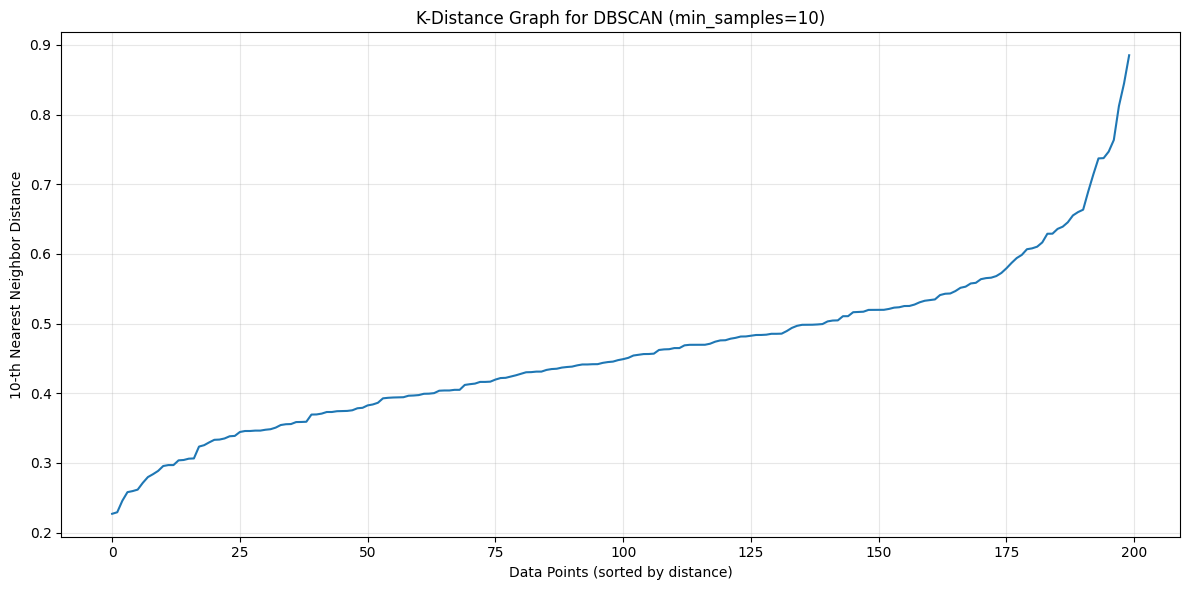

Estimated optimal eps: 0.5682
Testing eps values: [0.2841 0.4261 0.5682 0.7102 0.8522]


,eps,min_samples,n_clusters,n_noise,noise_%,silhouette,davies,calinski
0,0.284078,10,2,174,87.0,0.889361,0.153487,867.947037
1,0.426116,10,4,41,20.5,0.218410,0.769181,36.687344
2,0.568155,10,1,1,0.5,NaN,NaN,NaN
3,0.710194,10,1,0,0.0,NaN,NaN,NaN
4,0.852233,10,1,0,0.0,NaN,NaN,NaN



Best eps chosen: 0.28407758941134054
eps              0.284078
min_samples     10.000000
n_clusters       2.000000
n_noise        174.000000
noise_%         87.000000
silhouette       0.889361
davies           0.153487
calinski       867.947037
Name: 0, dtype: float64

Final DBSCAN on FULL data
Clusters: 2
Noise points: 174 (87.00%)
Silhouette: 0.8894
Davies-Bouldin: 0.1535
Calinski-Harabasz: 867.9470


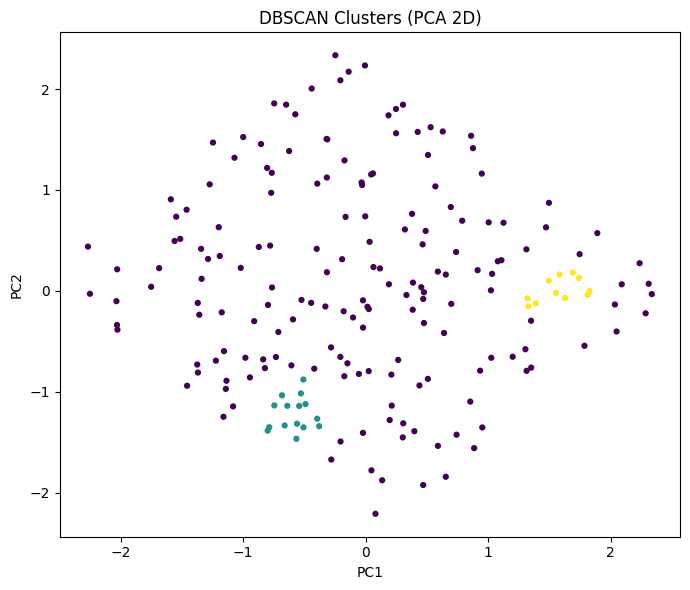

In [ ]:
print("="*50)
print("DBSCAN CLUSTERING - Machine Failure Dataset")
print("="*50)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


df_work = df.copy()

drop_cols = ["UDI", "Product ID"]
drop_cols = [c for c in drop_cols if c in df_work.columns]
df_work = df_work.drop(columns=drop_cols)

if "Machine failure" in df_work.columns:
    df_work = df_work.drop(columns=["Machine failure"])

for c in ["TWF", "HDF", "PWF", "OSF", "RNF"]:
    if c in df_work.columns:
        df_work = df_work.drop(columns=[c])

if "Type" in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["Type"], drop_first=True)

df_work = df_work.dropna()

scaler = StandardScaler()
X_dbscan = scaler.fit_transform(df_work)

print("Final clustering feature shape:", X_dbscan.shape)


sample_n = min(5000, X_dbscan.shape[0])
rng = np.random.RandomState(42)
idx = rng.choice(X_dbscan.shape[0], size=sample_n, replace=False)
X_sample = X_dbscan[idx]

print(f"Using sample size = {sample_n} for eps estimation/tuning")

dim = X_sample.shape[1]
min_samples = max(10, dim + 1)  
print(f"Using min_samples = {min_samples}")

neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_sample)
distances, _ = neighbors.kneighbors(X_sample)
k_dist = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(12, 6))
plt.plot(k_dist)
plt.xlabel("Data Points (sorted by distance)")
plt.ylabel(f"{min_samples}-th Nearest Neighbor Distance")
plt.title(f"K-Distance Graph for DBSCAN (min_samples={min_samples})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

try:
    from kneed import KneeLocator
    kneedle = KneeLocator(range(len(k_dist)), k_dist, S=1.0, curve="convex", direction="increasing")
    knee_idx = kneedle.knee
    optimal_eps = k_dist[knee_idx] if knee_idx is not None else np.percentile(k_dist, 98)
except:
    knee_idx = None
    optimal_eps = np.percentile(k_dist, 98)

print(f"Estimated optimal eps: {optimal_eps:.4f}")


eps_values = np.linspace(optimal_eps * 0.5, optimal_eps * 1.5, 5)
print("Testing eps values:", np.round(eps_values, 4))

dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=float(eps), min_samples=min_samples, metric="euclidean", n_jobs=-1)
    labels = dbscan.fit_predict(X_sample)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_pct = (n_noise / len(labels)) * 100

    mask = labels != -1
    if n_clusters > 1 and mask.sum() > 0:
        sil = silhouette_score(X_sample[mask], labels[mask])
        dbi = davies_bouldin_score(X_sample[mask], labels[mask])
        chi = calinski_harabasz_score(X_sample[mask], labels[mask])
    else:
        sil, dbi, chi = np.nan, np.nan, np.nan

    dbscan_results.append({
        "eps": float(eps),
        "min_samples": min_samples,
        "n_clusters": int(n_clusters),
        "n_noise": int(n_noise),
        "noise_%": float(noise_pct),
        "silhouette": sil,
        "davies": dbi,
        "calinski": chi
    })

dbscan_df = pd.DataFrame(dbscan_results)
display(dbscan_df)

best_row = dbscan_df.sort_values(["silhouette", "noise_%"], ascending=[False, True]).iloc[0]
best_eps = best_row["eps"]

print("\nBest eps chosen:", best_eps)
print(best_row)


dbscan_final = DBSCAN(eps=float(best_eps), min_samples=min_samples, n_jobs=-1)
labels_full = dbscan_final.fit_predict(X_dbscan)

n_clusters_full = len(set(labels_full)) - (1 if -1 in labels_full else 0)
n_noise_full = np.sum(labels_full == -1)

print("\nFinal DBSCAN on FULL data")
print("Clusters:", n_clusters_full)
print("Noise points:", n_noise_full, f"({n_noise_full/len(labels_full)*100:.2f}%)")


mask_full = labels_full != -1
if n_clusters_full > 1 and mask_full.sum() > 0:
    sil_full = silhouette_score(X_dbscan[mask_full], labels_full[mask_full])
    dbi_full = davies_bouldin_score(X_dbscan[mask_full], labels_full[mask_full])
    chi_full = calinski_harabasz_score(X_dbscan[mask_full], labels_full[mask_full])
    print(f"Silhouette: {sil_full:.4f}")
    print(f"Davies-Bouldin: {dbi_full:.4f}")
    print(f"Calinski-Harabasz: {chi_full:.4f}")
else:
    print("Not enough clusters for metrics on full data.")


X_vis = PCA(n_components=2, random_state=42).fit_transform(X_dbscan)

plt.figure(figsize=(7,6))
plt.scatter(X_vis[:,0], X_vis[:,1], c=labels_full, s=12)
plt.title("DBSCAN Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


# Cell 11: Model Comparison and Analysis

MODEL COMPARISON: K-MEANS vs DBSCAN (AUTO SAMPLE)
Using DBSCAN params: eps=0.28407758941134054, min_samples=10
Sample size for comparison: 5,000

Model Performance Comparison (SAME SAMPLE):


,Model,Silhouette (↑),Davies-Bouldin (↓),Calinski-Harabasz (↑),Clusters (sample),Noise % (sample),Inertia (KMeans only)
0,K-Means,0.248906,1.321068,889.541348,3,0.0,51098.596197
1,DBSCAN,NaN,NaN,NaN,0,100.0,NaN


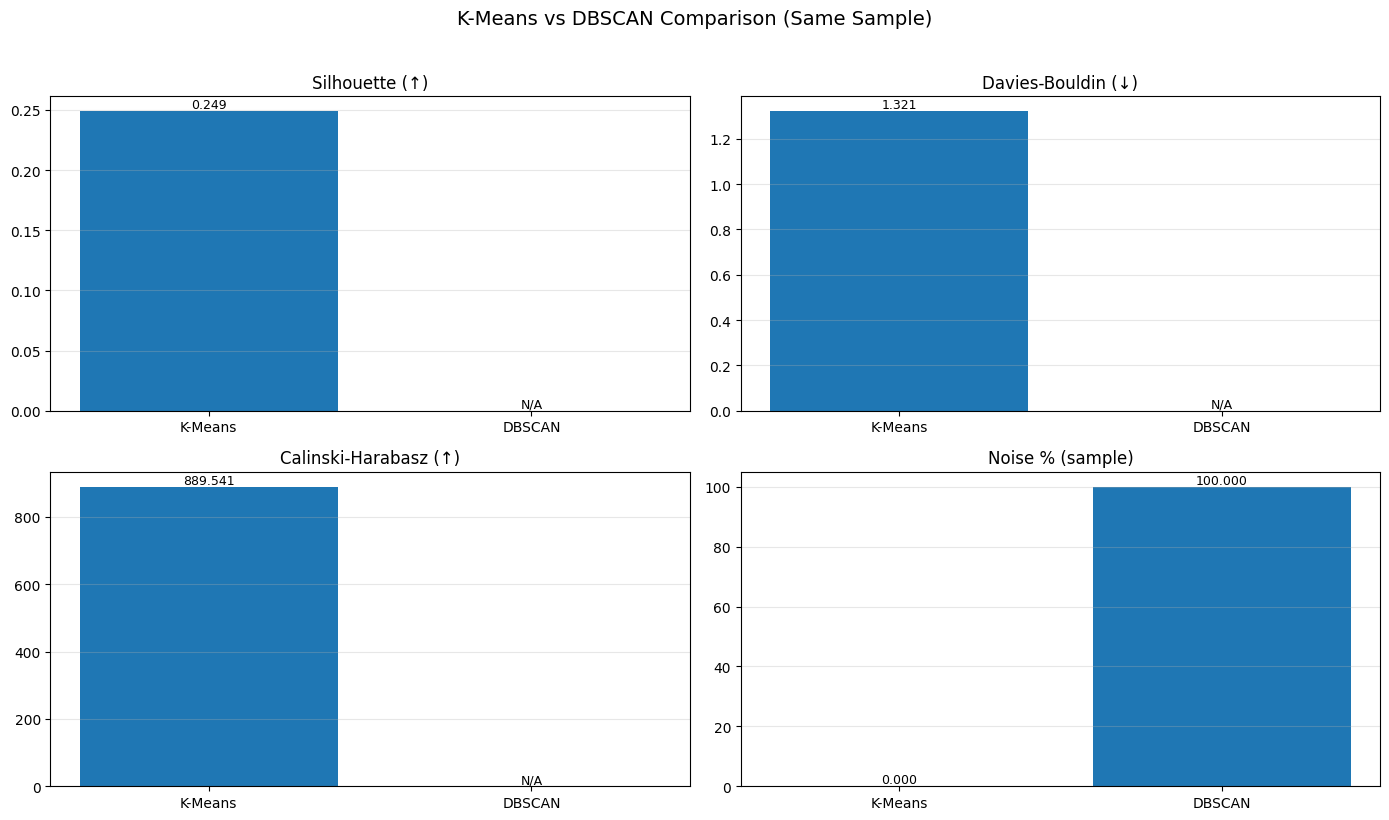


DBSCAN produced all noise; agreement metrics not available.

FINAL NOTE
- K-Means: forces all points into k clusters.
- DBSCAN: can find clusters + noise points.
- Better model on this sample: K-Means
  Silhouette: KMeans=0.249 vs DBSCAN=N/A
  DBSCAN noise%=100.00%


In [ ]:
print("="*50)
print("MODEL COMPARISON: K-MEANS vs DBSCAN (AUTO SAMPLE)")
print("="*50)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score




best_eps = best_eps if "best_eps" in globals() else (eps_value if "eps_value" in globals() else 0.5)
min_samples = min_samples if "min_samples" in globals() else (minPts if "minPts" in globals() else 10)

print(f"Using DBSCAN params: eps={best_eps}, min_samples={min_samples}")


sample_n = min(5000, len(X_kmeans))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_kmeans), sample_n, replace=False)

X_sample = X_kmeans.iloc[sample_idx].copy()

print(f"Sample size for comparison: {len(X_sample):,}")


labels_kmeans = kmeans_final.predict(X_sample)

dbscan_sample_model = DBSCAN(eps=float(best_eps), min_samples=int(min_samples), n_jobs=-1)
labels_dbscan = dbscan_sample_model.fit_predict(X_sample)


k_sil = silhouette_score(X_sample, labels_kmeans)
k_dav = davies_bouldin_score(X_sample, labels_kmeans)
k_cal = calinski_harabasz_score(X_sample, labels_kmeans)
k_inertia = getattr(kmeans_final, "inertia_", np.nan)


n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db = int(np.sum(labels_dbscan == -1))
noise_pct_db = (n_noise_db / len(labels_dbscan)) * 100

mask = labels_dbscan != -1
n_clusters_valid = len(set(labels_dbscan[mask])) if mask.sum() > 0 else 0

if n_clusters_valid >= 2:
    d_sil = silhouette_score(X_sample[mask], labels_dbscan[mask])
    d_dav = davies_bouldin_score(X_sample[mask], labels_dbscan[mask])
    d_cal = calinski_harabasz_score(X_sample[mask], labels_dbscan[mask])
else:
    d_sil, d_dav, d_cal = np.nan, np.nan, np.nan


comparison_df = pd.DataFrame({
    "Model": ["K-Means", "DBSCAN"],
    "Silhouette (↑)": [k_sil, d_sil],
    "Davies-Bouldin (↓)": [k_dav, d_dav],
    "Calinski-Harabasz (↑)": [k_cal, d_cal],
    "Clusters (sample)": [kmeans_final.n_clusters, n_clusters_db],
    "Noise % (sample)": [0.0, noise_pct_db],
    "Inertia (KMeans only)": [k_inertia, np.nan],
})

print("\nModel Performance Comparison (SAME SAMPLE):")
display(comparison_df)


fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
cols = ["Silhouette (↑)", "Davies-Bouldin (↓)", "Calinski-Harabasz (↑)", "Noise % (sample)"]

for ax, col in zip(axes, cols):
    vals = comparison_df[col].fillna(0).values
    ax.bar(comparison_df["Model"], vals)
    ax.set_title(col)
    ax.grid(True, alpha=0.3, axis="y")
    for i, v in enumerate(comparison_df[col].values):
        txt = "N/A" if np.isnan(v) else (f"{v:.3f}" if abs(v) < 1000 else f"{v:,.0f}")
        ax.text(i, vals[i], txt, ha="center", va="bottom", fontsize=9)

plt.suptitle("K-Means vs DBSCAN Comparison (Same Sample)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

 
mask_agree = labels_dbscan != -1
if mask_agree.sum() > 0:
    ari = adjusted_rand_score(labels_kmeans[mask_agree], labels_dbscan[mask_agree])
    nmi = normalized_mutual_info_score(labels_kmeans[mask_agree], labels_dbscan[mask_agree])
    print("\n" + "="*50)
    print("CLUSTER AGREEMENT (excluding DBSCAN noise)")
    print("="*50)
    print(f"Used points: {mask_agree.sum():,} / {len(labels_dbscan):,}")
    print(f"ARI: {ari:.4f}")
    print(f"NMI: {nmi:.4f}")
else:
    print("\nDBSCAN produced all noise; agreement metrics not available.")

 print("\n" + "="*50)
print("FINAL NOTE")
print("="*50)

better = "K-Means"
if not np.isnan(d_sil) and d_sil > k_sil:
    better = "DBSCAN"

print(f"- K-Means: forces all points into k clusters.")
print(f"- DBSCAN: can find clusters + noise points.")
print(f"- Better model on this sample: {better}")
print(f"  Silhouette: KMeans={k_sil:.3f} vs DBSCAN={d_sil if not np.isnan(d_sil) else 'N/A'}")
print(f"  DBSCAN noise%={noise_pct_db:.2f}%")
